RNN is a type of sequential model to work on sequential data.
Textual data are sequential data as there is certain meaning associated with the data only if it is in a correct sequential manner. Similarly there are time series data, speech data, DNA Sequences data which are examples of sequential data. We also cannot use ANN models for the work on sequential data, because the text inputs are varying size, we if we design a ANN we cannot make the layers dynamic. Furthermore if we try to pad the small sized texts with 0s and make such ANN layer such that the first layer will have neurons which will be equal to the number of the max size of the input then, then there arises many different problems like our computation would be much bigger and also as there will be lots of 0s, so the information will be lost. Also if we have this architecture, then there would be problem with the prediction also, as the max length of the prediction will have to be less than or equal to the max length of the input text. Sequential information will be lost in ANN architecture.

Backpropagation in RNN is called Backpropagation in time.

Let's take an example of sentiment analysis. This will be a classification problem. The inputs will be movie review texts. If our vocabulary consists of 5 words eg. - [movie,was,good,bad,not] then we can denote the word 'movie' by [1,0,0,0,0]; 'good' by [0,1,0,0,0] ... 'not' by [0,0,0,0,1]. If our review1 (input statement - training data) is 'movie was good' then we can denote it by the vector [[1,0,0,0,0],[0,1,0,0,0],[0,0,1,0,0]]. We feed the network with input_features with time one by one; when we send the first word it is called time=1, second word at time=2 and so on. We convert our words in vectors initially. So the shape of review1(input data) is (3,5) here i.e. (time_steps, input_features) where 3 is the number of time_steps as there is 3 words in the input text and the 5 is the number of input features in our data.

If the review 2 is 'movie was not good' then the respective vector would be [[1,0,0,0,0],[0,1,0,0,0],[0,0,0,0,1],[0,0,1,0,0]] with shape (4,5) and so on etc. In Keras, the input size into a simpleRNN class is (batchsize, timesteps, input_features).

In RNNs, there is a concept of step i.e. in RNNs the hidden layers gives feedback to itself after a forward pass. Lets take an example where we are building a RNN architecture with 5 input features, 3 hidden layers(this will be the recurrent layers) and 1 output node with sigmoid activation fnc. Below is how the network looks.

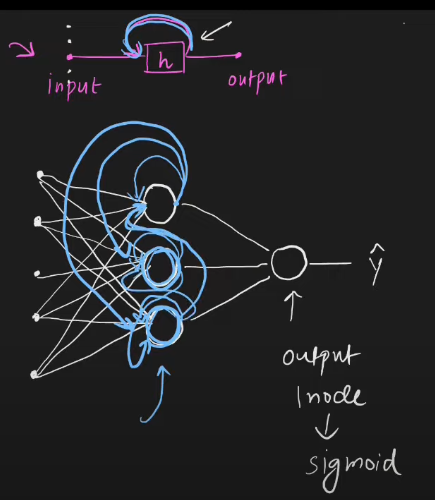

The output of each node will be used as an input of the same node as well as all the other nodes in the next time step. A better representation would be like as follows:

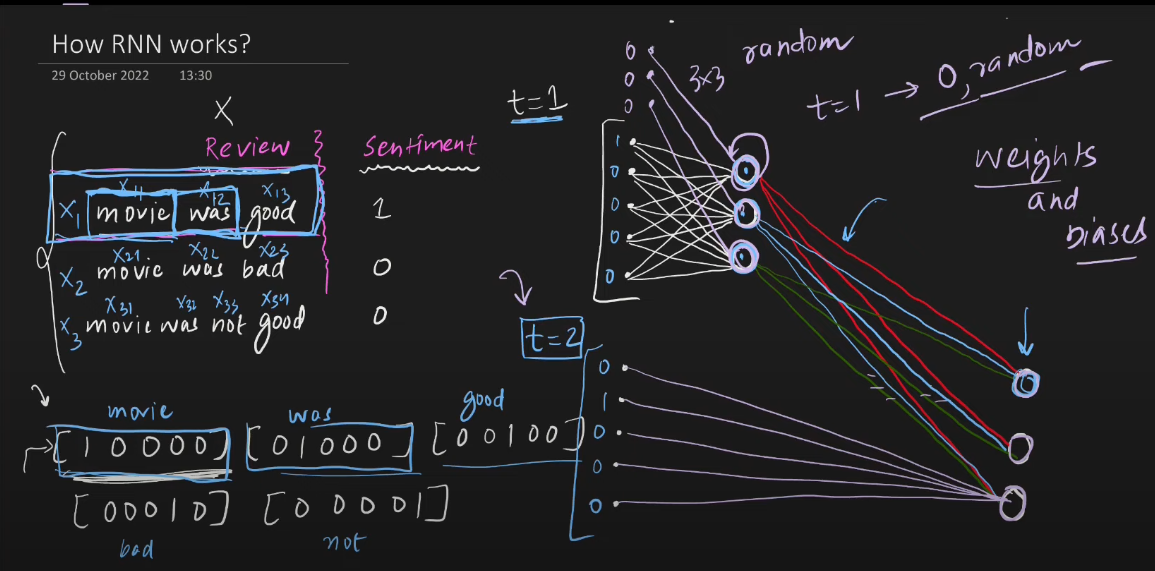

At t=1 we are sending the word 'movie' with the corresponding vector[1,0,0,0,0] into the network, where the outputs will be available in the hidden layers and from each node the activation i.e. the output will be sent to the same hidden layers at time=2; so at time=2 there will be the input vector of the 2nd word 'was' with the corresponding vector [0,1,0,0,0] as well as those activations from time=1.

An interesting question arises here—From time=2 the recurrent layer is getting output from the previous time=1 cycle; but at time=1 what previous inputs are the recurrent layer getting? The answer to this question is, we give Zeros or Random Numbers in the input for the first cycle to the recurrent layer.

How many weights and biases are there in this architecture? In the network, b/w the input and the recurrent layer the weight matrix is of size (5,3) i.e. b/w the input layer and the recurrent layer there are 15 weights; the output node is connected with 3 nodes of hidden layers making the weight matrix (3,1) and number of weights 3. The hidden connection have also weights; as there are 3 hidden layers and each is connected with every other, so the number of weights in the recurrent layer is (3,3) i.e 9 weights. So the total weights = 15 b/w input layer and recurrent layer + 9 inside the recurrent layer + 3 b/w the recurrent layer and the output layer = 27 weights in total and 3 bias in recurrent layer and 1 output bias totaling 4 biases in the architecture. So this architecture has 27+4=31 trainable parameters.

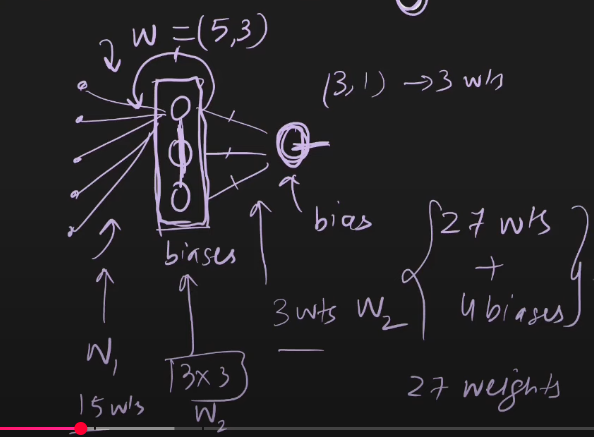
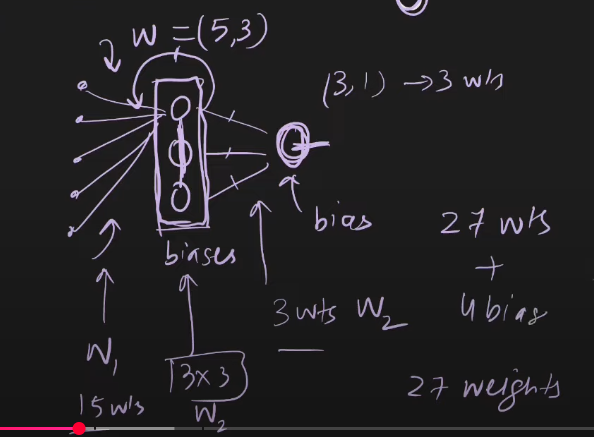
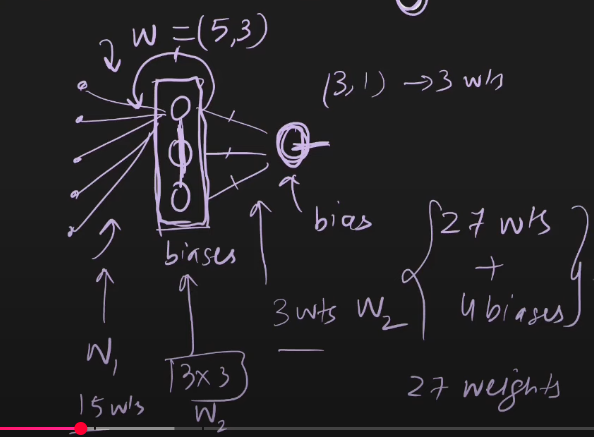

In [2]:
# from keras import Sequential
# from keras.layers import Dense, SimpleRNN
# import tensorflow
from tensorflow.keras import Sequential
from tensorflow.keras.layers  import Dense, SimpleRNN

In [4]:
model = Sequential()
model.add(SimpleRNN(3, input_shape=(4,5)))
# In above 4 is the number of max num of timesteps and 5 represents the num of features
model.add(Dense(1, activation='sigmoid')) # Adding Dense layer with 1 node

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Lets see the trainable parameters

print(model.get_weights()[0].shape)
model.get_weights()[0]

# This is the weight matrix b/w the input layer and the recurrent layer.

(5, 3)


array([[-0.31178492, -0.23118412,  0.73501354],
       [-0.45288935, -0.14681578, -0.20710218],
       [-0.77729064, -0.37415037, -0.49263817],
       [ 0.3542586 , -0.46759877, -0.63371015],
       [ 0.6359119 ,  0.08791381,  0.0293467 ]], dtype=float32)

In [16]:
print(model.get_weights()[1].shape)
model.get_weights()[1]

# This is the weight matrix inside the recurrent layer i.e the feedback network.

(3, 3)


array([[-0.04375422,  0.33074114, -0.94270664],
       [ 0.9313267 ,  0.35498986,  0.08131927],
       [-0.3615469 ,  0.8744098 ,  0.32356042]], dtype=float32)

In [15]:
print(model.get_weights()[2].shape)
model.get_weights()[2]

# This is the 3 bias in the recurrent layer

(3,)


array([0., 0., 0.], dtype=float32)

In [14]:
print(model.get_weights()[3].shape)
model.get_weights()[3]

# This is the weight matrix b/w the recurrent layer and the output layer

(3, 1)


array([[0.6990229 ],
       [1.0411919 ],
       [0.70437443]], dtype=float32)

In [13]:
print(model.get_weights()[4].shape)
model.get_weights()[4]

# This is the single bias in the output layer

(1,)


array([0.], dtype=float32)